### Import Libraries

In [2]:
try:
    import country_converter
except ImportError:
    !pip install country_converter
    import country_converter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 2.8 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import xml.etree.ElementTree as ET
import plotly.express as px
import country_converter as coco

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from io import BytesIO
from sklearn.cluster import DBSCAN
from decimal import Decimal
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN


#### Mount google drive

In [5]:
from google.colab import drive
drive.mount('/content/gdrive/')

%cd 'gdrive/My Drive/BigDataProject'

Mounted at /content/gdrive/
/content/gdrive/My Drive/BigDataProject


### Load Data

In [6]:
def fetch_oecd_data(api_url):
    """
    Fetches and parses OECD SDMX-JSON data from a given API URL and returns a clean DataFrame.

    Parameters:
        api_url (str): The full API URL for OECD SDMX-JSON data

    Returns:
        pd.DataFrame: Parsed data in tabular form
    """
    headers = {
        "Accept": "application/vnd.sdmx.data+json;version=1.0.0-wd"
    }

    response = requests.get(api_url, headers=headers)

    data = response.json()
    obs = data['data']['dataSets'][0]['observations']
    dimensions = data['data']['structure']['dimensions']['observation']

    dim_names = [d['name'] for d in dimensions]
    dim_values = [d['values'] for d in dimensions]

    records = []
    for key, val in obs.items():
        idx = list(map(int, key.split(":")))
        record = {dim_names[i]: dim_values[i][idx[i]]['name'] for i in range(len(idx))}
        record['value'] = val[0]
        records.append(record)

    return pd.DataFrame(records)

In [7]:
urls = {
    "Outlook": "https://sdmx.oecd.org/public/rest/data/OECD.TAD.ATM,DSD_AGR@DF_OUTLOOK_2024_2033,1.1/.A._T...?endPeriod=2033&dimensionAtObservation=AllDimensions",
    "PSE": "https://sdmx.oecd.org/public/rest/data/OECD.TAD.ARP,DSD_AGR_POLIND@DF_PSE,1.1/.A.PSE..USD?startPeriod=2014&dimensionAtObservation=AllDimensions",
    "TSE": "https://sdmx.oecd.org/public/rest/data/OECD.TAD.ARP,DSD_AGR_POLIND@DF_TSE,1.1/.A.TSE..USD?startPeriod=2014&dimensionAtObservation=AllDimensions",
    "SoilErosion": "https://sdmx.oecd.org/public/rest/data/OECD.TAD.ARP,DSD_AGRI_ENV@DF_AGSE,1.0/.A.WATER_SOIL....?dimensionAtObservation=AllDimensions",
    "Agri_env": "https://sdmx.oecd.org/public/rest/data/OECD.TAD.ARP,DSD_AGRI_ENV@DF_AEI,1.0/.A.TOTAGR_LAND....HA?dimensionAtObservation=AllDimensions",
    "Pesticides_use ": "https://sdmx.oecd.org/public/rest/data/OECD.TAD.ARP,DSD_AGRI_ENV@DF_AGPEST,1.0/.A.TOTPEST....?startPeriod=2012&dimensionAtObservation=AllDimensions",
    "Greenhouse_gas": "https://sdmx.oecd.org/public/rest/data/OECD.TAD.ARP,DSD_AGRI_ENV@DF_AGGHGSEM,1.0/.A.TOTGHG_GAZ....?dimensionAtObservation=AllDimensions",
    "Energy_use": "https://sdmx.oecd.org/public/rest/data/OECD.TAD.ARP,DSD_AGRI_ENV@DF_AGNRJ,1.0/.A.TOTNRJAG....?dimensionAtObservation=AllDimensions",
    "Water_quality": "https://sdmx.oecd.org/public/rest/data/OECD.TAD.ARP,DSD_AGRI_ENV@DF_AGWQ,1.0/.A...SW..PT_EM_NO3?dimensionAtObservation=AllDimensions",
    "Nutrients_Nitrogen": "https://sdmx.oecd.org/public/rest/data/OECD.TAD.ARP,DSD_AGRI_ENV@DF_NB,1.0/.A.B0_H...NITROGEN.KG?dimensionAtObservation=AllDimensions",
    "Nutrients_Phosphorus": "https://sdmx.oecd.org/public/rest/data/OECD.TAD.ARP,DSD_AGRI_ENV@DF_NB,1.0/.A.B0_H...PHOSPHORUS.KG?dimensionAtObservation=AllDimensions",
    "water_use": "https://sdmx.oecd.org/public/rest/data/OECD.TAD.ARP,DSD_AGRI_ENV@DF_AGWATER,1.0/.A.TOTFRESHW.._T..M3?dimensionAtObservation=AllDimensions"
}


The new dataset is an updated and corrected version of the previous data_full, addressing missing values in Water type, Nutrients, and Erosion risk level by integrating additional datasets. It also includes new Energy use information.  

The currently used datasets are:  
  - Nutrient Balances  
  - Pesticides Use  
  - Producer Support Estimate (PSE)  
  - Total Support Estimate (TSE)  
  - Soil Erosion  
  - OECD-FAO Agricultural Outlook 2024-2033  
  - Energy Use  
  - Agri-environmental Indicators: All Data  
  - Agricultural Greenhouse Gas Emissions  
  - Water use
  - Water quality

**Brief DataFrame Description**

The file **data\_full.csv** contains the relevant factors identified during yesterday’s meeting.

---

Special Measures:
* **Water type**: from the *Water Quality* dataset, we selected **surface water**.
* **Agricultural output**: from the *Agricultural Outlook* dataset, we selected **all commodities**.

---

* Most column names are adopted directly from the original datasets, with each measure’s unit appended to its name.
* Since most datasets do not include continent‐level aggregates, the entries in the **Country** column for continents (e.g. “Africa”) reflect sums **only** from the Outlook dataset—not the total across all sources.
* The most complete time span is **2014–2022**. Data for **2024–2033** are all forecasts drawn from the Outlook dataset.
* Many countries have incomplete records. The most comprehensively covered economies are:

  * 38 OECD member countries
  * 5 non-OECD EU member states
  * 11 emerging economies: Argentina, Brazil, People’s Republic of China, India, Indonesia, Kazakhstan, the Philippines, the Russian Federation, South Africa, Ukraine, and Viet Nam.


In [8]:
dfs = []
for name, url in urls.items():
    df_tmp = fetch_oecd_data(url)
    df_tmp['Metric'] = name  # label the data source
    dfs.append(df_tmp)


In [9]:
combined_df = pd.concat(dfs, ignore_index=True)

#### View the data

In [10]:
combined_df.head()

,Reference area,Frequency of observation,Commodity,Measure,Unit of measure,Version ID,Time period,value,Metric,Erosion risk level,Water type,Nutrients
0,Japan,Annual,All Commodities,Food fat availability,Grammes per person per day,Agricultural Outlook 2024-2033,1990,0.0,Outlook,NaN,NaN,NaN
1,Japan,Annual,All Commodities,Food fat availability,Grammes per person per day,Agricultural Outlook 2024-2033,1991,0.0,Outlook,NaN,NaN,NaN
2,Japan,Annual,All Commodities,Food fat availability,Grammes per person per day,Agricultural Outlook 2024-2033,1992,0.0,Outlook,NaN,NaN,NaN
3,Japan,Annual,All Commodities,Food fat availability,Grammes per person per day,Agricultural Outlook 2024-2033,1993,0.0,Outlook,NaN,NaN,NaN
4,Japan,Annual,All Commodities,Food fat availability,Grammes per person per day,Agricultural Outlook 2024-2033,1994,0.0,Outlook,NaN,NaN,NaN


In [11]:
combined_df.shape

(17045, 12)

In [12]:
print(combined_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17045 entries, 0 to 17044
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Reference area            17045 non-null  object 
 1   Frequency of observation  17045 non-null  object 
 2   Commodity                 6632 non-null   object 
 3   Measure                   17045 non-null  object 
 4   Unit of measure           17045 non-null  object 
 5   Version ID                6052 non-null   object 
 6   Time period               17045 non-null  object 
 7   value                     16994 non-null  float64
 8   Metric                    17045 non-null  object 
 9   Erosion risk level        10413 non-null  object 
 10  Water type                10413 non-null  object 
 11  Nutrients                 10413 non-null  object 
dtypes: float64(1), object(11)
memory usage: 1.6+ MB
None


### Data Pre-process

In [112]:
df = combined_df.copy()

#### Check the missing value

In [113]:
print("=== Missing ratio by column ===")
print(df.isna().mean())

=== Missing ratio by column ===
Reference area              0.000000
Frequency of observation    0.000000
Commodity                   0.610912
Measure                     0.000000
Unit of measure             0.000000
Version ID                  0.644940
Time period                 0.000000
value                       0.002992
Metric                      0.000000
Erosion risk level          0.389088
Water type                  0.389088
Nutrients                   0.389088
dtype: float64


#### Process the columns

In [114]:
df.rename(columns={
    'Reference area': 'Country',
    'Time period':    'Year',
    'value':          'Value'
}, inplace=True)

In [115]:
# Process column names
df['Measure_Unit'] = df['Measure'] + ' (' + df['Unit of measure'] + ')'

df.drop(columns=['Measure', 'Unit of measure'], inplace=True)

meta = [
    'Country', 'Year',
    'Frequency of observation','Commodity',
    'Version ID','Erosion risk level',
    'Water type','Nutrients'
]

df_indexed = df.set_index(meta + ['Measure_Unit'])

df_wide = df_indexed['Value'].unstack('Measure_Unit').reset_index()

df_wide.columns.name = None

print(df_wide.columns.tolist())
df_wide.head()

['Country', 'Year', 'Frequency of observation', 'Commodity', 'Version ID', 'Erosion risk level', 'Water type', 'Nutrients', 'Balance per hectare (Kilogramme)', 'Direct on-farm energy consumption (Tonnes of oil equivalent)', 'Food fat availability (Grammes per person per day)', 'Food protein availability (Grammes per person per day)', 'Producer Support Estimate (PSE) (US dollar)', 'Share of agriculture in total emissions of nitrate (Percentage of nitrate emissions)', 'Total Support Estimate (TSE) (US dollar)', 'Total agricultural land area (Hectares)', 'Total calorie availability (Kilocalories per person per day)', 'Total freshwater abstraction (Cubic metres)', 'Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent)', 'Total sales of agricultural pesticides (Tonnes)', 'Water erosion (Percentage of agricultural land area)']


,Country,Year,Frequency of observation,Commodity,Version ID,Erosion risk level,Water type,Nutrients,Balance per hectare (Kilogramme),Direct on-farm energy consumption (Tonnes of oil equivalent),...,Food protein availability (Grammes per person per day),Producer Support Estimate (PSE) (US dollar),Share of agriculture in total emissions of nitrate (Percentage of nitrate emissions),Total Support Estimate (TSE) (US dollar),Total agricultural land area (Hectares),Total calorie availability (Kilocalories per person per day),Total freshwater abstraction (Cubic metres),Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent),Total sales of agricultural pesticides (Tonnes),Water erosion (Percentage of agricultural land area)
0,Africa,1990,Annual,All Commodities,Agricultural Outlook 2024-2033,NaN,NaN,NaN,NaN,NaN,...,0.0000,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN
1,Africa,1991,Annual,All Commodities,Agricultural Outlook 2024-2033,NaN,NaN,NaN,NaN,NaN,...,0.0000,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN
2,Africa,1992,Annual,All Commodities,Agricultural Outlook 2024-2033,NaN,NaN,NaN,NaN,NaN,...,51.8476,NaN,NaN,NaN,NaN,2039.3465,NaN,NaN,NaN,NaN
3,Africa,1993,Annual,All Commodities,Agricultural Outlook 2024-2033,NaN,NaN,NaN,NaN,NaN,...,55.7047,NaN,NaN,NaN,NaN,2176.5519,NaN,NaN,NaN,NaN
4,Africa,1994,Annual,All Commodities,Agricultural Outlook 2024-2033,NaN,NaN,NaN,NaN,NaN,...,55.9360,NaN,NaN,NaN,NaN,2187.9973,NaN,NaN,NaN,NaN


In [116]:
df_wide.shape

(8919, 21)

In [117]:
df_wide.columns

Index(['Country', 'Year', 'Frequency of observation', 'Commodity',
       'Version ID', 'Erosion risk level', 'Water type', 'Nutrients',
       'Balance per hectare (Kilogramme)',
       'Direct on-farm energy consumption (Tonnes of oil equivalent)',
       'Food fat availability (Grammes per person per day)',
       'Food protein availability (Grammes per person per day)',
       'Producer Support Estimate (PSE) (US dollar)',
       'Share of agriculture in total emissions of nitrate (Percentage of nitrate emissions)',
       'Total Support Estimate (TSE) (US dollar)',
       'Total agricultural land area (Hectares)',
       'Total calorie availability (Kilocalories per person per day)',
       'Total freshwater abstraction (Cubic metres)',
       'Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent)',
       'Total sales of agricultural pesticides (Tonnes)',
       'Water erosion (Percentage of agricultural land area)'],
      dtype='object')

In [118]:
len(df_wide.columns)

21

In [119]:
print("=== Missing ratio by column ===")
print(df_wide.isna().mean())

=== Missing ratio by column ===
Country                                                                                 0.000000
Year                                                                                    0.000000
Frequency of observation                                                                0.000000
Commodity                                                                               0.740554
Version ID                                                                              0.773069
Erosion risk level                                                                      0.259446
Water type                                                                              0.259446
Nutrients                                                                               0.259446
Balance per hectare (Kilogramme)                                                        0.632694
Direct on-farm energy consumption (Tonnes of oil equivalent)                            0.76970

In [120]:
print(df_wide.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8919 entries, 0 to 8918
Data columns (total 21 columns):
 #   Column                                                                                Non-Null Count  Dtype  
---  ------                                                                                --------------  -----  
 0   Country                                                                               8919 non-null   object 
 1   Year                                                                                  8919 non-null   object 
 2   Frequency of observation                                                              8919 non-null   object 
 3   Commodity                                                                             2314 non-null   object 
 4   Version ID                                                                            2024 non-null   object 
 5   Erosion risk level                                                                 

#### Process categorical variables

In [123]:
df_wide['Commodity'].unique()

array(['All Commodities', nan, 'Total indicators'], dtype=object)

In [124]:
df_wide['Version ID'].unique()

array(['Agricultural Outlook 2024-2033', nan], dtype=object)

The metadata specification of our datasets indicates the presence of non-predictive categorical columns functioning purely as dataset descriptors. As these metadata artifacts provide no analytical value, we are executing targeted column pruning through our feature space optimization protocol, thereby enhancing computational efficiency while maintaining core data integrity.

In [22]:
df_wide = df_wide.drop(columns=['Erosion risk level', 'Water type', 'Commodity','Version ID' ])

#### Adjust Nutrients Column

In [23]:
df_wide['Nutrients'].unique()

array([nan, 'Nitrogen', 'Not applicable', 'Phosphorus'], dtype=object)

The Nutrients column contains distinct entries for nitrogen and phosphorus fertilizers amidst irrelevant data, requiring targeted extraction of these specific nutrient parameters.

This process will be performed through structured nutrient profiling while establishing validation protocols to ensure precise isolation of the chemical indicators.

In [24]:
df_origin = combined_df.copy()

In [25]:
df_origin.head()

,Reference area,Frequency of observation,Commodity,Measure,Unit of measure,Version ID,Time period,value,Metric,Erosion risk level,Water type,Nutrients
0,Japan,Annual,All Commodities,Food fat availability,Grammes per person per day,Agricultural Outlook 2024-2033,1990,0.0,Outlook,NaN,NaN,NaN
1,Japan,Annual,All Commodities,Food fat availability,Grammes per person per day,Agricultural Outlook 2024-2033,1991,0.0,Outlook,NaN,NaN,NaN
2,Japan,Annual,All Commodities,Food fat availability,Grammes per person per day,Agricultural Outlook 2024-2033,1992,0.0,Outlook,NaN,NaN,NaN
3,Japan,Annual,All Commodities,Food fat availability,Grammes per person per day,Agricultural Outlook 2024-2033,1993,0.0,Outlook,NaN,NaN,NaN
4,Japan,Annual,All Commodities,Food fat availability,Grammes per person per day,Agricultural Outlook 2024-2033,1994,0.0,Outlook,NaN,NaN,NaN


In [26]:
df_origin.rename(columns={
    'Reference area': 'Country',
    'Time period':    'Year',
    'value':          'Value'
}, inplace=True)

In [27]:
df_nut = df_origin[df_origin['Metric'].str.startswith('Nutrients_')].copy()

df_nut['Measure_Unit'] = (
    df_nut['Nutrients'] + ' ' +
    df_nut['Measure'] + ' (' +
    df_nut['Unit of measure'] + ')'
)

df_nut_wide = (
    df_nut
    .pivot_table(
        index=['Country','Year'],
        columns='Measure_Unit',
        values='Value',
        aggfunc='mean'
    )
    .reset_index()
)

# merge
df_nutrient = df_wide.merge(
    df_nut_wide,
    on=['Country','Year'],
    how='left'
)

In [28]:
df_nutrient.head()

,Country,Year,Frequency of observation,Nutrients,Balance per hectare (Kilogramme),Direct on-farm energy consumption (Tonnes of oil equivalent),Food fat availability (Grammes per person per day),Food protein availability (Grammes per person per day),Producer Support Estimate (PSE) (US dollar),Share of agriculture in total emissions of nitrate (Percentage of nitrate emissions),Total Support Estimate (TSE) (US dollar),Total agricultural land area (Hectares),Total calorie availability (Kilocalories per person per day),Total freshwater abstraction (Cubic metres),Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent),Total sales of agricultural pesticides (Tonnes),Water erosion (Percentage of agricultural land area),Nitrogen Balance per hectare (Kilogramme),Phosphorus Balance per hectare (Kilogramme)
0,Africa,1990,Annual,NaN,NaN,NaN,0.0,0.0000,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa,1991,Annual,NaN,NaN,NaN,0.0,0.0000,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
2,Africa,1992,Annual,NaN,NaN,NaN,0.0,51.8476,NaN,NaN,NaN,NaN,2039.3465,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa,1993,Annual,NaN,NaN,NaN,0.0,55.7047,NaN,NaN,NaN,NaN,2176.5519,NaN,NaN,NaN,NaN,NaN,NaN
4,Africa,1994,Annual,NaN,NaN,NaN,0.0,55.9360,NaN,NaN,NaN,NaN,2187.9973,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
df_nutrient.shape

(8919, 19)

In [30]:
df_wide = df_nutrient.drop(columns=['Nutrients',"Balance per hectare (Kilogramme)"])

In [31]:
print(df_wide.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8919 entries, 0 to 8918
Data columns (total 17 columns):
 #   Column                                                                                Non-Null Count  Dtype  
---  ------                                                                                --------------  -----  
 0   Country                                                                               8919 non-null   object 
 1   Year                                                                                  8919 non-null   object 
 2   Frequency of observation                                                              8919 non-null   object 
 3   Direct on-farm energy consumption (Tonnes of oil equivalent)                          2054 non-null   float64
 4   Food fat availability (Grammes per person per day)                                    2024 non-null   float64
 5   Food protein availability (Grammes per person per day)                             

Unfortunately, our diagnostic analysis reveals pervasive missing values indicating severely constrained data quality. However, we remain committed to developing a methodological framework that will systematically diagnose the etiology of these data gaps through pattern recognition algorithms, while implementing targeted remediation strategies to preserve analytical validity.

#### Duplication Checking


Before further data wrangling, we need to ensure there are no duplicate entries for each year and country combination first, only one row should exist in the dataset.

In [32]:
counts = (
    df_wide
    .groupby(['Country','Year'])
    .size()
    .reset_index(name='count')
)

dup_groups = counts[counts['count'] > 1]
total_group_dup = dup_groups['count'].sum()

In [33]:
counts = df_wide.groupby(['Country','Year']).size().reset_index(name='count')
duplicates = counts[counts['count'] > 1]
print(duplicates)

        Country  Year  count
44    Argentina  1985      3
45    Argentina  1986      3
46    Argentina  1987      3
47    Argentina  1988      3
48    Argentina  1989      3
...         ...   ...    ...
3256   Viet Nam  2019      5
3257   Viet Nam  2020      5
3258   Viet Nam  2021      3
3259   Viet Nam  2022      2
3260   Viet Nam  2023      2

[1938 rows x 3 columns]


In [34]:
total_group_dup = dup_groups['count'].sub(1).sum()  # Subtract 1 from each count

In [35]:
print(f"Duplication numbers: {total_group_dup}")

Duplication numbers: 5600


Our quality audit has revealed 5,600 duplicated rows constituting over 50% of the original dataset's volume. Through implementation of systematic deduplication protocols, we maintain confidence that addressing these redundancies will substantially enhance data integrity while preserving critical agricultural indicators.

#### Duplication Process

In [36]:
num_cols = df_wide.select_dtypes(include=[np.number]).columns.tolist()

df_num = (
    df_wide
    .groupby(['Country','Year'])[num_cols]
    .mean()
    .reset_index()
)

cat_cols = ['Frequency of observation']

df_cat = (
    df_wide
    .groupby(['Country','Year'])[cat_cols]
    .first()
    .reset_index()
)

In [37]:
df_without_dupli = pd.merge(df_cat, df_num, on=['Country','Year'], how='inner')

In [38]:
print(f" Shape before duplication process {df_wide.shape}")
print(f" Shape after duplication process{df_without_dupli.shape}")
print(f" Reduced row numbers equal to detcted: {(df_wide.shape[0] - df_without_dupli.shape[0]) == total_group_dup}")

 Shape before duplication process (8919, 17)
 Shape after duplication process(3319, 17)
 Reduced row numbers equal to detcted: True


To be more precise, let us check the duplition again

In [39]:
counts = df_without_dupli.groupby(['Country','Year']).size().reset_index(name='count')
duplicates = counts[counts['count'] > 1]
print(duplicates)

Empty DataFrame
Columns: [Country, Year, count]
Index: []


In [40]:
df_without_dupli

,Country,Year,Frequency of observation,Direct on-farm energy consumption (Tonnes of oil equivalent),Food fat availability (Grammes per person per day),Food protein availability (Grammes per person per day),Producer Support Estimate (PSE) (US dollar),Share of agriculture in total emissions of nitrate (Percentage of nitrate emissions),Total Support Estimate (TSE) (US dollar),Total agricultural land area (Hectares),Total calorie availability (Kilocalories per person per day),Total freshwater abstraction (Cubic metres),Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent),Total sales of agricultural pesticides (Tonnes),Water erosion (Percentage of agricultural land area),Nitrogen Balance per hectare (Kilogramme),Phosphorus Balance per hectare (Kilogramme)
0,Africa,1990,Annual,NaN,0.0,0.0000,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa,1991,Annual,NaN,0.0,0.0000,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
2,Africa,1992,Annual,NaN,0.0,51.8476,NaN,NaN,NaN,NaN,2039.3465,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa,1993,Annual,NaN,0.0,55.7047,NaN,NaN,NaN,NaN,2176.5519,NaN,NaN,NaN,NaN,NaN,NaN
4,Africa,1994,Annual,NaN,0.0,55.9360,NaN,NaN,NaN,NaN,2187.9973,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3314,World,2029,Annual,NaN,0.0,89.8861,NaN,NaN,NaN,NaN,2926.6233,NaN,NaN,NaN,NaN,NaN,NaN
3315,World,2030,Annual,NaN,0.0,90.2471,NaN,NaN,NaN,NaN,2936.4405,NaN,NaN,NaN,NaN,NaN,NaN
3316,World,2031,Annual,NaN,0.0,90.6069,NaN,NaN,NaN,NaN,2946.2925,NaN,NaN,NaN,NaN,NaN,NaN
3317,World,2032,Annual,NaN,0.0,90.9370,NaN,NaN,NaN,NaN,2955.9671,NaN,NaN,NaN,NaN,NaN,NaN


As evidenced by the print output, the Country column contains non-national entities such as the geopolitical regions Africa and World, in addition to missing values requiring treatment.

Given that our analytical focus resides at the country-specific dimension, it is imperative to sanitize these entries in subsequent processing stages.

#### Country Information cleaning

Since the original dataframe contains many continent-level entries while our analysis focuses specifically on country-level dimensions, we need to clean the existing Country data by removing all continent-related information

The expected workflow is:

- First, we apply our existing continent‐based filter to exclude any non‐country entries.

- Next, we use the country_converter package to obtain an authoritative list of country names and filter the raw data again accordingly.

- We then compare the two resulting country sets—if they differ in size or membership, we print out the discrepancies for further investigation.

This two-pronged approach combines our domain-specific filtering with an external standard, ensuring we neither miss valid countries nor include incorrect labels due to naming inconsistencies in the source datasets.

##### Filter based on invalid names

Proceeding with the merged datasets' metadata descriptions, let us first compile a candidate list of non-standard entries, then apply a negative filter to the Country column using this exclusion list. This process will leverage validated country nomenclature references to ensure geopolitical entity validity.

In [41]:
invalid_names = [
    'Africa','Asia','Europe','Northern America',
    'Oceania','Latin America','World', 'European Union', 'European Union (28 countries)',
    'European Union (27 countries from 01/02/2020)','Non-OECD economies',
    'OECD'
]

In [42]:
df_continent_filtered = df_without_dupli[~df_without_dupli['Country'].isin(invalid_names)].copy()

In [43]:
print("Original row number：", df_without_dupli.shape[0])
print("Filtered row number：", df_continent_filtered.shape[0])
print("Remaining Country number：", df_continent_filtered['Country'].nunique())

Original row number： 3319
Filtered row number： 2854
Remaining Country number： 68


##### Filter based on the formal package

In [44]:
# use the same dataframe as the previous part
df_temp = df_without_dupli.copy()

In [45]:
cc = coco.CountryConverter()
valid_names = set(cc.data['name_short'])
df_lib_filtered = df_temp[df_temp['Country'].isin(valid_names)].copy()

In [46]:
set_cont = set(df_continent_filtered['Country'].unique())
set_lib  = set(df_lib_filtered['Country'].unique())

In [47]:
print("Filter by continent names: ", len(set_cont))
print("Filter by formal country names : ", len(set_lib))

Filter by continent names:  68
Filter by formal country names :  60


##### Analysis the difference

In [48]:
only_in_cont = set_cont - set_lib
only_in_lib  = set_lib  - set_cont

if only_in_cont or only_in_lib:
    print("Difference detected:")
    if only_in_cont:
        print("Only in continent filter, not in standard library list:", only_in_cont)
    if only_in_lib:
        print("Only in standard library filter, not in continent filter list:", only_in_lib)
else:
    print("Both filtering methods produced identical country sets.")


Difference detected:
Only in continent filter, not in standard library list: {'Developed countries', 'Slovak Republic', 'Developing countries', 'Korea', 'Flemish Region', 'China (People’s Republic of)', 'Viet Nam', 'Wallonia'}


The discrepancy analysis reveals two distinct issues: explicitly invalid entries like "Developed countries" requiring categorical exclusion, and potential nomenclature mismatches exemplified by the "Viet Nam" variation that may stem from dataset formatting inconsistencies.

To enhance filtering precision, we shall implement a dual approach - updating the exclusion list with these identified anomalies while establishing standardized country code references to mitigate typographical discrepancies.

In [49]:
invalid_name_complete = [
    'Africa','Asia','Europe','Northern America',
    'Oceania','Latin America','World', 'European Union', 'European Union (28 countries)',
    'European Union (27 countries from 01/02/2020)','Non-OECD economies',
    'OECD','Flemish Region','Developing countries','Wallonia','Developed countries'
]

In [50]:
df_continent_filtered_2 = df_without_dupli[~df_without_dupli['Country'].isin(invalid_name_complete)].copy()

In [51]:
print("Consider row numbers: ")
print("Original row number: ", df_without_dupli.shape[0])
print("First filtered row number: ", df_continent_filtered.shape[0])
print("Second filtered row number: ", df_continent_filtered_2.shape[0])
print( )
print("Consider remaining countries: ")
print("First Remaining Country number: ", df_continent_filtered['Country'].nunique())
print("Second Remaining Country number: ", df_continent_filtered_2['Country'].nunique())

Consider row numbers: 
Original row number:  3319
First filtered row number:  2854
Second filtered row number:  2742

Consider remaining countries: 
First Remaining Country number:  68
Second Remaining Country number:  64


In this stage, the newly filtered country names are detected above: 'Flemish Region','Developing countries','Wallonia' and 'Developed countries'.

In [52]:
df_countries = df_continent_filtered_2

In [53]:
df_countries

,Country,Year,Frequency of observation,Direct on-farm energy consumption (Tonnes of oil equivalent),Food fat availability (Grammes per person per day),Food protein availability (Grammes per person per day),Producer Support Estimate (PSE) (US dollar),Share of agriculture in total emissions of nitrate (Percentage of nitrate emissions),Total Support Estimate (TSE) (US dollar),Total agricultural land area (Hectares),Total calorie availability (Kilocalories per person per day),Total freshwater abstraction (Cubic metres),Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent),Total sales of agricultural pesticides (Tonnes),Water erosion (Percentage of agricultural land area),Nitrogen Balance per hectare (Kilogramme),Phosphorus Balance per hectare (Kilogramme)
44,Argentina,1985,Annual,1539.515,NaN,NaN,NaN,NaN,NaN,127384.0,NaN,NaN,NaN,NaN,NaN,-1.960,2.229
45,Argentina,1986,Annual,1572.553,NaN,NaN,NaN,NaN,NaN,127384.0,NaN,NaN,NaN,NaN,NaN,-1.296,2.250
46,Argentina,1987,Annual,1721.436,NaN,NaN,NaN,NaN,NaN,127384.0,NaN,NaN,NaN,NaN,NaN,-1.154,2.283
47,Argentina,1988,Annual,1695.518,NaN,NaN,NaN,NaN,NaN,127380.0,NaN,NaN,NaN,NaN,NaN,-1.262,2.129
48,Argentina,1989,Annual,1472.949,NaN,NaN,NaN,NaN,NaN,127470.0,NaN,NaN,NaN,NaN,NaN,-0.208,2.470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3266,Viet Nam,2029,Annual,NaN,0.0,99.6546,NaN,NaN,NaN,NaN,3020.4865,NaN,NaN,NaN,NaN,NaN,NaN
3267,Viet Nam,2030,Annual,NaN,0.0,100.9089,NaN,NaN,NaN,NaN,3046.4422,NaN,NaN,NaN,NaN,NaN,NaN
3268,Viet Nam,2031,Annual,NaN,0.0,102.2272,NaN,NaN,NaN,NaN,3072.7372,NaN,NaN,NaN,NaN,NaN,NaN
3269,Viet Nam,2032,Annual,NaN,0.0,103.4687,NaN,NaN,NaN,NaN,3098.0171,NaN,NaN,NaN,NaN,NaN,NaN


We will continue our further data wrangling with the new data frame: "df_countries"

#### Decimals process

To ensure computational integrity in downstream analyses, precision standardization is being systematically implemented across all numerical vectors. This methodological imperative involves constraining all floating-point representations to uniform decimal precision through explicit type casting protocols, thereby eliminating potential artifacts arising from inconsistent numerical resolution.

In [54]:
df_agg = df_countries.copy()

In [55]:
num_cols = df_agg.select_dtypes(include='number').columns
df_agg[num_cols] = df_agg[num_cols].round(2)

In [56]:
round_dict = {} # No special decimal requirement, all default, 2f

In [57]:
df_agg[num_cols.difference(round_dict.keys())] = df_agg[num_cols.difference(round_dict.keys())].round(3)

for col, prec in round_dict.items():
    if col in df_agg.columns:
        df_agg[col] = df_agg[col].round(prec)

In [58]:
def count_decimals_decimal(x):
    """
    Use Decimal(str(x)) to get precise decimal places count.
    normalize() will remove trailing zeros.
    """
    d = Decimal(str(x)).normalize()
    exp = d.as_tuple().exponent
    return -exp if exp < 0 else 0


In [59]:
for col in num_cols:
    places = df_agg[col].dropna().map(count_decimals_decimal).unique()
    print(f"{col}: decimal places → {places}")
    if len(places) == 3:
        print(f"{col} has consistent decimal places: {places[0]} digits")
    else:
        print(f"{col} has inconsistent decimal places, found {len(places)} variations: {places}")


Direct on-farm energy consumption (Tonnes of oil equivalent): decimal places → [2 1 0]
Direct on-farm energy consumption (Tonnes of oil equivalent) has consistent decimal places: 2 digits
Food fat availability (Grammes per person per day): decimal places → [0]
Food fat availability (Grammes per person per day) has inconsistent decimal places, found 1 variations: [0]
Food protein availability (Grammes per person per day): decimal places → [0 2 1]
Food protein availability (Grammes per person per day) has consistent decimal places: 0 digits
Producer Support Estimate (PSE) (US dollar): decimal places → [2 1 0]
Producer Support Estimate (PSE) (US dollar) has consistent decimal places: 2 digits
Share of agriculture in total emissions of nitrate (Percentage of nitrate emissions): decimal places → [0 2 1]
Share of agriculture in total emissions of nitrate (Percentage of nitrate emissions) has consistent decimal places: 0 digits
Total Support Estimate (TSE) (US dollar): decimal places → [2 1 0

In [60]:
df_agg.head()

,Country,Year,Frequency of observation,Direct on-farm energy consumption (Tonnes of oil equivalent),Food fat availability (Grammes per person per day),Food protein availability (Grammes per person per day),Producer Support Estimate (PSE) (US dollar),Share of agriculture in total emissions of nitrate (Percentage of nitrate emissions),Total Support Estimate (TSE) (US dollar),Total agricultural land area (Hectares),Total calorie availability (Kilocalories per person per day),Total freshwater abstraction (Cubic metres),Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent),Total sales of agricultural pesticides (Tonnes),Water erosion (Percentage of agricultural land area),Nitrogen Balance per hectare (Kilogramme),Phosphorus Balance per hectare (Kilogramme)
44,Argentina,1985,Annual,1539.52,NaN,NaN,NaN,NaN,NaN,127384.0,NaN,NaN,NaN,NaN,NaN,-1.96,2.23
45,Argentina,1986,Annual,1572.55,NaN,NaN,NaN,NaN,NaN,127384.0,NaN,NaN,NaN,NaN,NaN,-1.30,2.25
46,Argentina,1987,Annual,1721.44,NaN,NaN,NaN,NaN,NaN,127384.0,NaN,NaN,NaN,NaN,NaN,-1.15,2.28
47,Argentina,1988,Annual,1695.52,NaN,NaN,NaN,NaN,NaN,127380.0,NaN,NaN,NaN,NaN,NaN,-1.26,2.13
48,Argentina,1989,Annual,1472.95,NaN,NaN,NaN,NaN,NaN,127470.0,NaN,NaN,NaN,NaN,NaN,-0.21,2.47


### Further Data Wrangling

#### Help Functions

In [107]:
def plot_variable_trend(df, variable, top_n=25):
    """
    Draw a time trend chart of the specified variable by country (top N countries)
    """
    top_countries = df['Country'].value_counts().head(top_n).index.tolist()
    df_sub = df[df['Country'].isin(top_countries)]

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_sub, x='Year', y=variable, hue='Country', marker='o')
    plt.title(f"{variable} time trend")
    plt.ylabel(variable)
    plt.xlabel("Year")
    plt.legend(loc="center left", title="Country")
    plt.tight_layout()
    plt.show()


def safe_merge_on_country_year(df_main, df_to_merge, value_column, source_name):
    """
    Safely merges an external dataset into the main DataFrame using 'Country' and 'Year'.

    Parameters:
    - df_main: pd.DataFrame, the main dataset
    - df_to_merge: pd.DataFrame, dataset to merge in
    - value_column: str, column in df_to_merge to bring into df_main
    - source_name: str, label to append for the new column (e.g. 'OECD', 'FAO')

    Returns:
    - pd.DataFrame with the merged column added
    """

    df_main['Country'] = df_main['Country'].astype(str)
    df_main['Year'] = df_main['Year'].astype(int)

    df_to_merge = df_to_merge.rename(columns={
        'Country': 'Country',
        'Year': 'Year',
        value_column: f"{value_column} [{source_name}]"
    })
    df_to_merge['Country'] = df_to_merge['Country'].astype(str)
    df_to_merge['Year'] = df_to_merge['Year'].astype(int)

    merged = df_main.merge(
        df_to_merge[['Country', 'Year', f"{value_column} [{source_name}]"]],
        on=['Country', 'Year'],
        how='left',
        validate='1:1'  # Ensures no duplicates sneak in
    )

    return merged

def plot_missing_by_year(df, numerical_columns):
    """
    Plot a heatmap of missing data by year for the specified numerical columns.
    """
    missing_by_year = df.groupby("Year")[numerical_columns].apply(lambda x: x.isnull().mean())
    plt.figure(figsize=(16, 6))
    sns.heatmap(missing_by_year.T, cmap="Reds", cbar_kws={'label': 'Fraction Missing'})
    plt.title("Missing Data Matrix by Year (Red = More Missing)")
    plt.xlabel("Year")
    plt.ylabel("Numerical Variables")
    plt.tight_layout()
    plt.show()

def missing_percent_by_variable(df, columns):
    """
    Calculates the percentage of missing values for each specified column.
    """
    missing_percent = df[columns].isnull().mean().sort_values(ascending=False) * 100
    return missing_percent.reset_index().rename(columns={'index': 'Variable', 0: '% Missing'})


def drop_columns_with_missing(df, columns, threshold, verbose):
    """
    Drops columns from the DataFrame if missingness exceeds the specified threshold.

    Parameters:
    - df: DataFrame to evaluate
    - columns: list of columns to check (default = all)
    - threshold: maximum allowed fraction of missing values (0-1)
    - verbose: if True, prints a summary of dropped columns

    Returns:
    - df_reduced: DataFrame with columns dropped
    - kept_columns: list of columns retained
    - dropped_columns: list of columns removed
    """
    if columns is None:
        columns = df.columns.tolist()

    missing_frac = df[columns].isnull().mean()
    dropped_columns = missing_frac[missing_frac > threshold].index.tolist()
    kept_columns = missing_frac[missing_frac <= threshold].index.tolist()

    df_reduced = df.drop(columns=dropped_columns)

    if verbose:
        print(f"Threshold = {threshold:.0%}")
        print(f"Kept columns: {len(kept_columns)}: {kept_columns}")
        print(f"Dropped columns ({len(dropped_columns)}): {dropped_columns}")

    return df_reduced, kept_columns, dropped_columns

def filter_countries_with_most_data(df, group_col='Country', threshold=10):
    """
    Filters the DataFrame to keep only countries with low missing values across variables.

    Parameters:
        df (pd.DataFrame): The input DataFrame.
        group_col (str): Column representing countries.
        threshold (float): Maximum missing value % allowed per variable.

    Returns:
        tuple:
            - Filtered DataFrame with selected countries.
            - DataFrame of missing % per variable for selected countries.
    """
    # Step 1: Calculate missing % per variable per country
    grouped = df.groupby(group_col, group_keys=False)
    missing_counts = grouped.apply(lambda g: g.drop(columns=group_col, errors='ignore').isnull().sum())
    total_counts = grouped.size()

    total_df = pd.DataFrame(index=missing_counts.index, columns=missing_counts.columns)
    for col in total_df.columns:
        total_df[col] = total_counts
    missing_pct = (missing_counts / total_df) * 100

    # Step 2: Keep only countries with all variables under threshold
    good_countries = missing_pct[missing_pct.le(threshold).all(axis=1)].index.tolist()

    # Step 3: Filter original DataFrame
    filtered_df = df[df[group_col].isin(good_countries)].copy()

    # Step 4: Recalculate missing % on filtered set
    grouped_filtered = filtered_df.groupby(group_col, group_keys=False)
    updated_missing = grouped_filtered.apply(lambda g: g.drop(columns=group_col, errors='ignore').isnull().sum())
    updated_total = grouped_filtered.size()

    updated_total_df = pd.DataFrame(index=updated_missing.index, columns=updated_missing.columns)
    for col in updated_total_df.columns:
        updated_total_df[col] = updated_total

    updated_missing_pct = (updated_missing / updated_total_df) * 100

    # Drop group_col from columns if duplicated
    if group_col in updated_missing_pct.columns:
        updated_missing_pct = updated_missing_pct.drop(columns=group_col)

    return filtered_df, updated_missing_pct.reset_index()

def plot_missing_by_year_and_country(df, numerical_columns, country_name):
    """
    Plot a heatmap of missing data by year for the specified numerical columns, filtered by a specific country.

    Parameters:
    - df: pandas DataFrame containing the data.
    - numerical_columns: list of numerical column names to assess.
    - country_name: string, the name of the country to filter for.
    """
    # Filter by country
    df_country = df[df["Country"] == country_name]

    # Calculate missing data fraction by year
    missing_by_year = df_country.groupby("Year")[numerical_columns].apply(lambda x: x.isnull().mean())

    # Plot heatmap
    plt.figure(figsize=(16, 6))
    sns.heatmap(missing_by_year.T, cmap="Reds", cbar_kws={'label': 'Fraction Missing'})
    plt.title(f"Missing Data Matrix by Year for {country_name} (Red = More Missing)")
    plt.xlabel("Year")
    plt.ylabel("Numerical Variables")
    plt.tight_layout()
    plt.show()

def plot_missing_by_country(df, numerical_columns, top_n=20):
    """
    Visualize, for each country, the fraction of missing values
    across the given numerical columns—and highlight the worst offenders.

    Parameters:
        df (pd.DataFrame): must include a 'Country' column.
        numerical_columns (List[str]): which numeric fields to check.
        top_n (int): show only the top N countries ranked by missing rate.
    """
    # Compute missing fraction per country & column
    miss_frac = (
        df.groupby("Country")[numerical_columns]
          .apply(lambda sub: sub.isnull().mean())
    )

    # Identify the top N countries by overall missingness
    overall = miss_frac.mean(axis=1)
    worst = overall.nlargest(top_n).index
    data = miss_frac.loc[worst]

    # Plot
    plt.figure(figsize=(12, max(6, 0.3*len(worst))))
    sns.heatmap(
        data,
        cmap="Reds",
        cbar_kws={'label': 'Fraction Missing'},
        linewidths=0.5,
        linecolor='gray'
    )
    plt.title(f"Missing‐Data Heatmap by Country (Top {top_n})")
    plt.xlabel("Variables")
    plt.ylabel("Country")
    plt.tight_layout()
    plt.show()


#### Data Type Transformation

Let us convert the Year column—originally stored as strings (e.g. "2015")—into integer type. It ensures we can perform numeric operations on years (like sorting or using them as numeric axes in plots) and that filtering/grouping by year works correctly.

In [62]:
df = df_agg.copy()

In [63]:
df['Year'] = df['Year'].astype(int)

In [64]:
df.head()

,Country,Year,Frequency of observation,Direct on-farm energy consumption (Tonnes of oil equivalent),Food fat availability (Grammes per person per day),Food protein availability (Grammes per person per day),Producer Support Estimate (PSE) (US dollar),Share of agriculture in total emissions of nitrate (Percentage of nitrate emissions),Total Support Estimate (TSE) (US dollar),Total agricultural land area (Hectares),Total calorie availability (Kilocalories per person per day),Total freshwater abstraction (Cubic metres),Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent),Total sales of agricultural pesticides (Tonnes),Water erosion (Percentage of agricultural land area),Nitrogen Balance per hectare (Kilogramme),Phosphorus Balance per hectare (Kilogramme)
44,Argentina,1985,Annual,1539.52,NaN,NaN,NaN,NaN,NaN,127384.0,NaN,NaN,NaN,NaN,NaN,-1.96,2.23
45,Argentina,1986,Annual,1572.55,NaN,NaN,NaN,NaN,NaN,127384.0,NaN,NaN,NaN,NaN,NaN,-1.30,2.25
46,Argentina,1987,Annual,1721.44,NaN,NaN,NaN,NaN,NaN,127384.0,NaN,NaN,NaN,NaN,NaN,-1.15,2.28
47,Argentina,1988,Annual,1695.52,NaN,NaN,NaN,NaN,NaN,127380.0,NaN,NaN,NaN,NaN,NaN,-1.26,2.13
48,Argentina,1989,Annual,1472.95,NaN,NaN,NaN,NaN,NaN,127470.0,NaN,NaN,NaN,NaN,NaN,-0.21,2.47


#### Check Missing Data

In [65]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 2742 entries, 44 to 3270
Data columns (total 17 columns):
 #   Column                                                                                Non-Null Count  Dtype  
---  ------                                                                                --------------  -----  
 0   Country                                                                               2742 non-null   object 
 1   Year                                                                                  2742 non-null   int64  
 2   Frequency of observation                                                              2742 non-null   object 
 3   Direct on-farm energy consumption (Tonnes of oil equivalent)                          1990 non-null   float64
 4   Food fat availability (Grammes per person per day)                                    1540 non-null   float64
 5   Food protein availability (Grammes per person per day)                                1

In [66]:
print("=== Missing ratio by column ===")
print(df.isna().mean())

=== Missing ratio by column ===
Country                                                                                 0.000000
Year                                                                                    0.000000
Frequency of observation                                                                0.000000
Direct on-farm energy consumption (Tonnes of oil equivalent)                            0.274252
Food fat availability (Grammes per person per day)                                      0.438366
Food protein availability (Grammes per person per day)                                  0.438366
Producer Support Estimate (PSE) (US dollar)                                             0.902626
Share of agriculture in total emissions of nitrate (Percentage of nitrate emissions)    0.957695
Total Support Estimate (TSE) (US dollar)                                                0.902626
Total agricultural land area (Hectares)                                                 0.35849

It is obvious that the processed data frame is much better now, but it still has some problem

#### Missing Value Handling

##### Country Selection

In [67]:
numerical_columns = df.select_dtypes(include='number').columns
df["Country"].unique(), df["Country"].nunique()

(array(['Argentina', 'Australia', 'Austria', 'Belgium', 'Brazil',
        'Bulgaria', 'Canada', 'Chile', 'China (People’s Republic of)',
        'Colombia', 'Costa Rica', 'Croatia', 'Cyprus', 'Czechia',
        'Denmark', 'Egypt', 'Estonia', 'Ethiopia', 'Finland', 'France',
        'Germany', 'Greece', 'Hungary', 'Iceland', 'India', 'Indonesia',
        'Iran', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kazakhstan',
        'Korea', 'Latvia', 'Lithuania', 'Luxembourg', 'Malaysia', 'Malta',
        'Mexico', 'Netherlands', 'New Zealand', 'Nigeria', 'Norway',
        'Pakistan', 'Paraguay', 'Peru', 'Philippines', 'Poland',
        'Portugal', 'Romania', 'Russia', 'Saudi Arabia', 'Slovak Republic',
        'Slovenia', 'South Africa', 'Spain', 'Sweden', 'Switzerland',
        'Thailand', 'Türkiye', 'Ukraine', 'United Kingdom',
        'United States', 'Viet Nam'], dtype=object),
 64)

<ipython-input-68-c3e7fa0f166f>:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


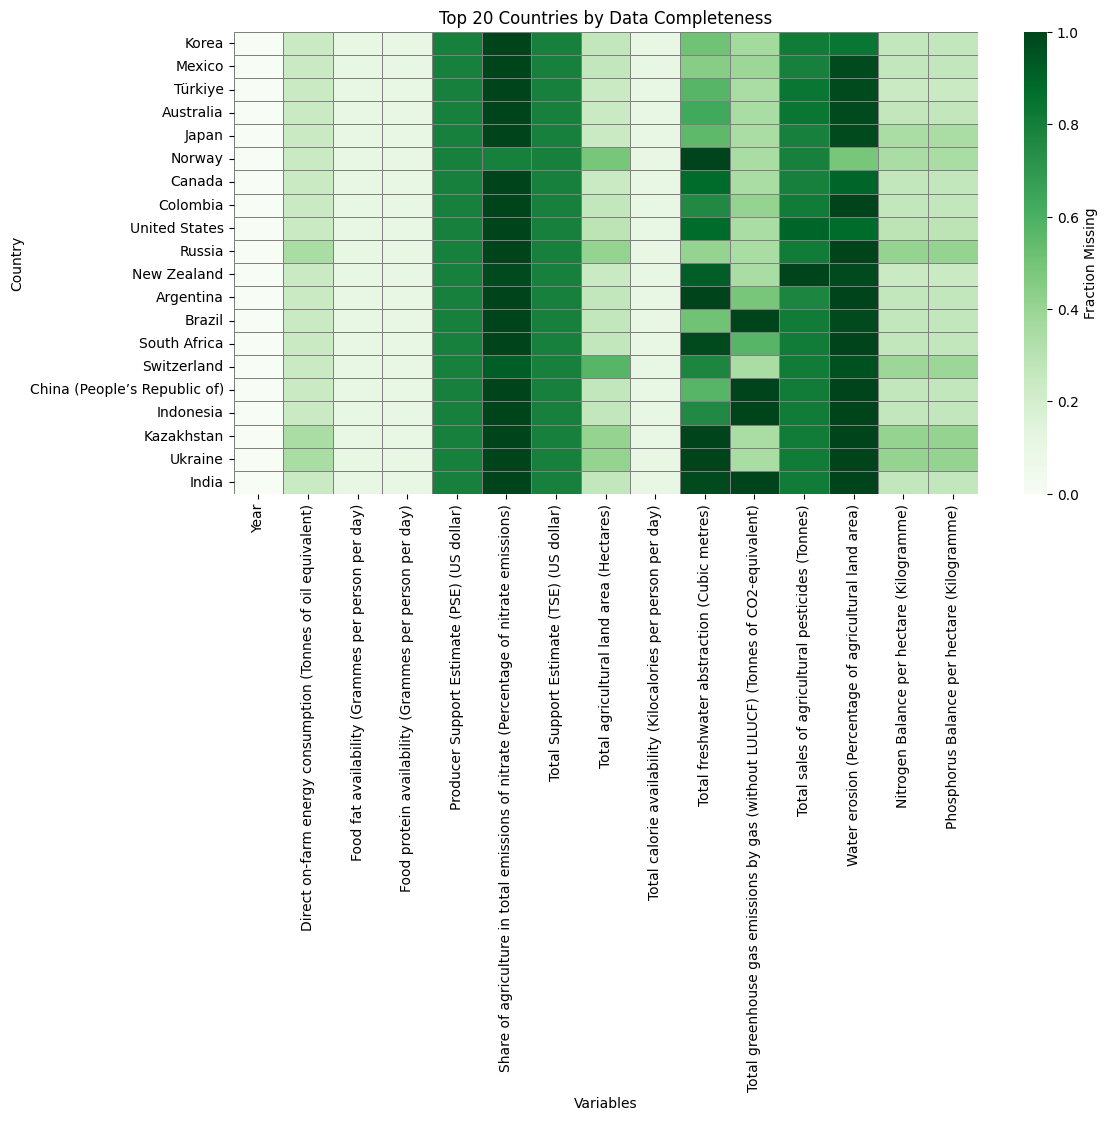

In [68]:
top_n = 20
miss_frac = df.groupby("Country")[numerical_columns].apply(lambda x: x.isnull().mean())
overall = miss_frac.mean(axis=1)

# top_n with smallest missing
best_countries = overall.nsmallest(top_n).index
data_best = miss_frac.loc[best_countries]

# heatmap
plt.figure(figsize=(12, max(6, 0.3*len(best_countries))))
sns.heatmap(
    data_best,
    cmap="Greens",
    cbar_kws={'label': 'Fraction Missing'},
    linewidths=0.5,
    linecolor='gray'
)
plt.title(f"Top {top_n} Countries by Data Completeness")
plt.xlabel("Variables")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [69]:
# filter data based on best countiries to keep
df_countires_best = df[df["Country"].isin(best_countries)].copy()

Hence, we have narrowed down the companies we can use for our analysis. From 68 to 20.

In [70]:
df_countires_best["Country"].unique(), df_countires_best["Country"].nunique()

(array(['Argentina', 'Australia', 'Brazil', 'Canada',
        'China (People’s Republic of)', 'Colombia', 'India', 'Indonesia',
        'Japan', 'Kazakhstan', 'Korea', 'Mexico', 'New Zealand', 'Norway',
        'Russia', 'South Africa', 'Switzerland', 'Türkiye', 'Ukraine',
        'United States'], dtype=object),
 20)

##### Time Period Selection

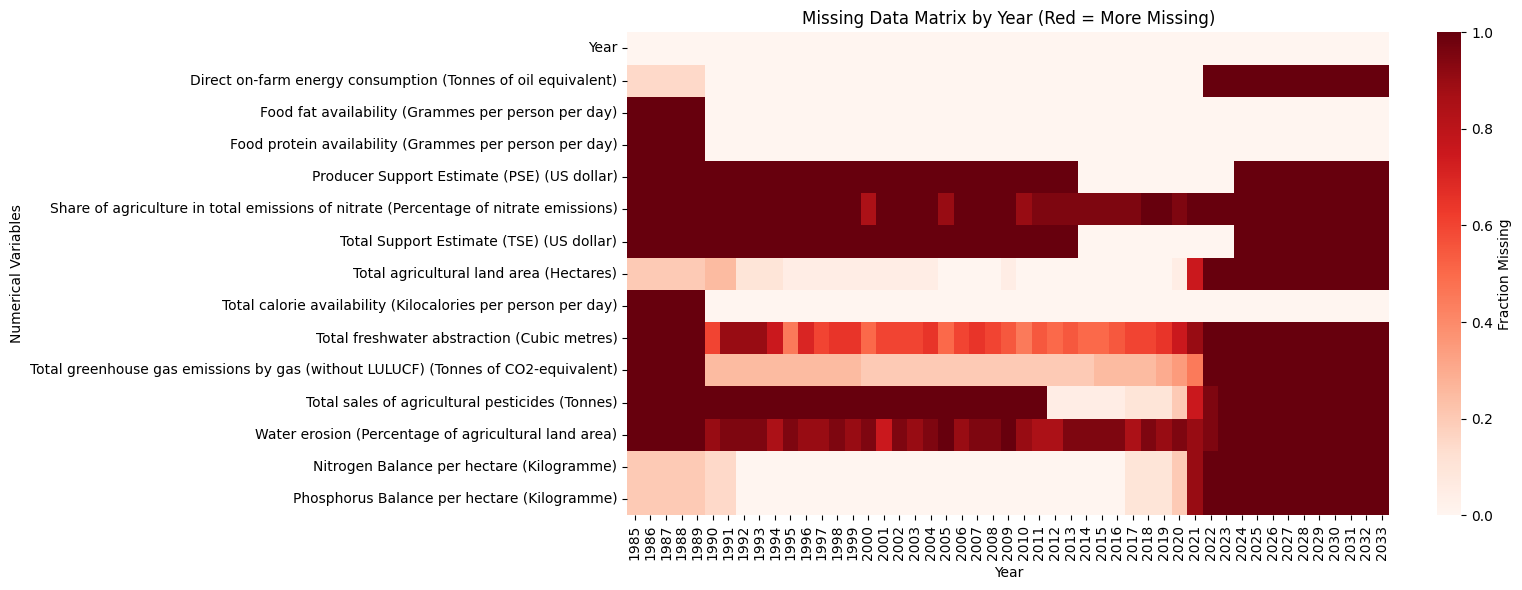

In [71]:
plot_missing_by_year(df_countires_best, numerical_columns)

In [72]:
df_time_best = df_countires_best[df_countires_best['Year'].between(2012, 2020)].copy()

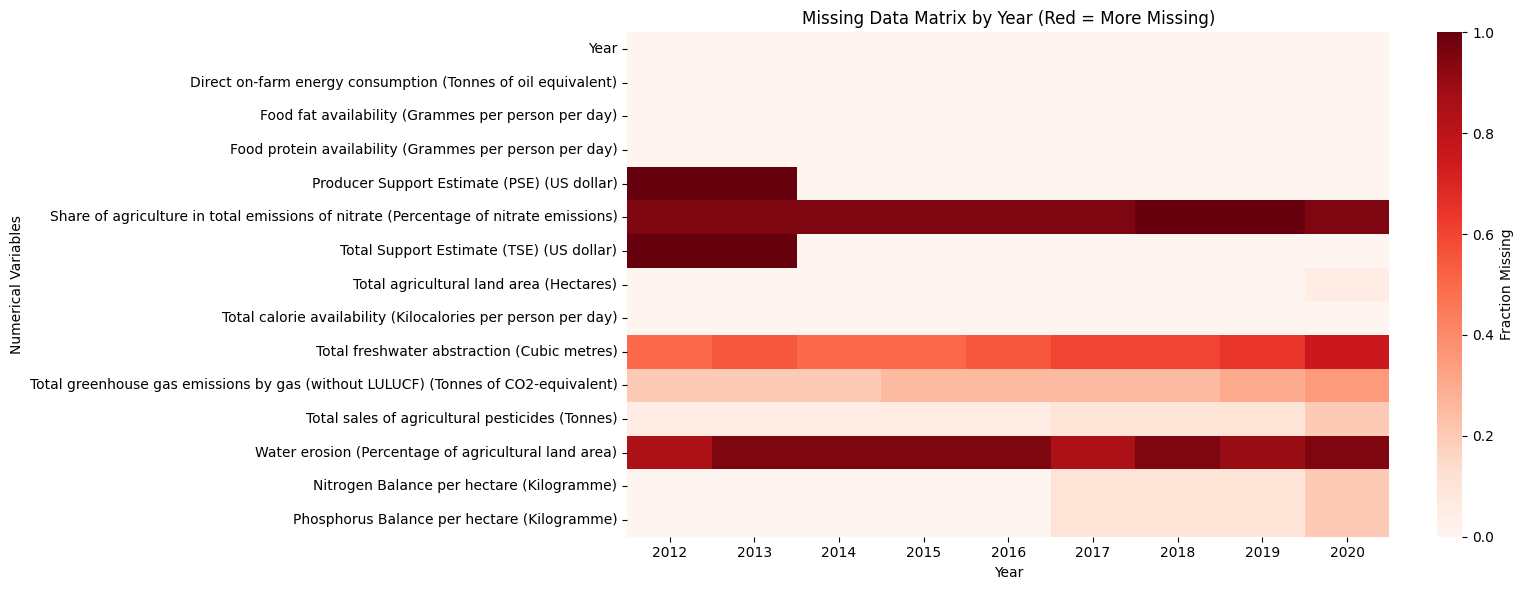

In [73]:
plot_missing_by_year(df_time_best, numerical_columns)

##### Feature Selection

In [74]:
df_time_best.isnull().mean().sort_values(ascending=False) * 100

,0
Share of agriculture in total emissions of nitrate (Percentage of nitrate emissions),96.111111
Water erosion (Percentage of agricultural land area),92.222222
Total freshwater abstraction (Cubic metres),57.777778
Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent),25.000000
Total Support Estimate (TSE) (US dollar),22.222222
Producer Support Estimate (PSE) (US dollar),22.222222
Total sales of agricultural pesticides (Tonnes),8.333333
Phosphorus Balance per hectare (Kilogramme),5.555556
Nitrogen Balance per hectare (Kilogramme),5.555556
Total agricultural land area (Hectares),0.555556


In [75]:
df_reduced, kept_columns, dropped_columns = drop_columns_with_missing(df_time_best, columns=numerical_columns, threshold=0.60,verbose=True)

Threshold = 60%
Kept columns: 13: ['Year', 'Direct on-farm energy consumption (Tonnes of oil equivalent)', 'Food fat availability (Grammes per person per day)', 'Food protein availability (Grammes per person per day)', 'Producer Support Estimate (PSE) (US dollar)', 'Total Support Estimate (TSE) (US dollar)', 'Total agricultural land area (Hectares)', 'Total calorie availability (Kilocalories per person per day)', 'Total freshwater abstraction (Cubic metres)', 'Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent)', 'Total sales of agricultural pesticides (Tonnes)', 'Nitrogen Balance per hectare (Kilogramme)', 'Phosphorus Balance per hectare (Kilogramme)']
Dropped columns (2): ['Share of agriculture in total emissions of nitrate (Percentage of nitrate emissions)', 'Water erosion (Percentage of agricultural land area)']


In [76]:
df_reduced.isnull().mean().sort_values(ascending=False) * 100

,0
Total freshwater abstraction (Cubic metres),57.777778
Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent),25.000000
Producer Support Estimate (PSE) (US dollar),22.222222
Total Support Estimate (TSE) (US dollar),22.222222
Total sales of agricultural pesticides (Tonnes),8.333333
Phosphorus Balance per hectare (Kilogramme),5.555556
Nitrogen Balance per hectare (Kilogramme),5.555556
Total agricultural land area (Hectares),0.555556
Food fat availability (Grammes per person per day),0.000000
Food protein availability (Grammes per person per day),0.000000


In [77]:
kept_columns

['Year',
 'Direct on-farm energy consumption (Tonnes of oil equivalent)',
 'Food fat availability (Grammes per person per day)',
 'Food protein availability (Grammes per person per day)',
 'Producer Support Estimate (PSE) (US dollar)',
 'Total Support Estimate (TSE) (US dollar)',
 'Total agricultural land area (Hectares)',
 'Total calorie availability (Kilocalories per person per day)',
 'Total freshwater abstraction (Cubic metres)',
 'Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent)',
 'Total sales of agricultural pesticides (Tonnes)',
 'Nitrogen Balance per hectare (Kilogramme)',
 'Phosphorus Balance per hectare (Kilogramme)']

In [78]:
dropped_columns

['Share of agriculture in total emissions of nitrate (Percentage of nitrate emissions)',
 'Water erosion (Percentage of agricultural land area)']

#### Interpolation

In [79]:
df_reduced[kept_columns] = df_reduced[kept_columns].fillna(df_reduced[kept_columns].median())

In [80]:
df_reduced.isnull().sum()

,0
Country,0
Year,0
Frequency of observation,0
Direct on-farm energy consumption (Tonnes of oil equivalent),0
Food fat availability (Grammes per person per day),0
Food protein availability (Grammes per person per day),0
Producer Support Estimate (PSE) (US dollar),0
Total Support Estimate (TSE) (US dollar),0
Total agricultural land area (Hectares),0
Total calorie availability (Kilocalories per person per day),0


#### Visualization

In [83]:
df_reduced['Country'].unique()

array(['Argentina', 'Australia', 'Brazil', 'Canada',
       'China (People’s Republic of)', 'Colombia', 'India', 'Indonesia',
       'Japan', 'Kazakhstan', 'Korea', 'Mexico', 'New Zealand', 'Norway',
       'Russia', 'South Africa', 'Switzerland', 'Türkiye', 'Ukraine',
       'United States'], dtype=object)

In [93]:
# national name
countries = [
    'Argentina', 'Australia', 'Brazil', 'Canada',
    'China', 'Colombia', 'India', 'Indonesia',
    'Japan', 'Kazakhstan', 'South Korea', 'Mexico', 'New Zealand', 'Norway',
    'Russia', 'South Africa', 'Switzerland', 'Turkey', 'Ukraine',
    'United States'
]

# create DataFrame
df = pd.DataFrame({'country': countries, 'value': [1]*len(countries)})

# plot world map Plotly
fig = px.choropleth(
    df,
    locations='country',
    locationmode='country names',
    color='value',
    color_continuous_scale=['lightblue', 'steelblue'],
    range_color=(0, 1),
    title='Highlighted Countries on World Map'
)

fig.update_layout(
    coloraxis_showscale=False,
    width=1200,
    height=700
)

fig.show()

It is obvious that the chosen 20 countries span all six inhabited continents and include key agricultural exporters and importers, providing a broadly representative cross-section for our analysis.


In [103]:
print(df_reduced.info())

<class 'pandas.core.frame.DataFrame'>
Index: 180 entries, 71 to 3208
Data columns (total 15 columns):
 #   Column                                                                             Non-Null Count  Dtype  
---  ------                                                                             --------------  -----  
 0   Country                                                                            180 non-null    object 
 1   Year                                                                               180 non-null    int64  
 2   Frequency of observation                                                           180 non-null    object 
 3   Direct on-farm energy consumption (Tonnes of oil equivalent)                       180 non-null    float64
 4   Food fat availability (Grammes per person per day)                                 180 non-null    float64
 5   Food protein availability (Grammes per person per day)                             180 non-null    float64
 6

#### Save data

In [ ]:
df_reduced.to_csv("data_full.csv", index=False, encoding="utf-8-sig")

### Process Description

The following is the workflow of our Data Pre-process:

1. **Import Dependencies**

   * Load necessary libraries such as `import pandas as pd`, `import numpy as np`, and, if needed, `import matplotlib.pyplot as plt`.
   * This step guarantees availability of data manipulation and visualization functions throughout the pipeline.

2. **Mount Google Drive**

   * Execute `from google.colab import drive` and `drive.mount('/content/drive')` to attach the cloud storage.
   * Enables seamless loading and saving of large datasets without cluttering the local runtime.

3. **Data Acquisition**

   * Define a function  
     ```python
     def fetch_oecd_data(api_url: str) -> pd.DataFrame:
         # Calls the OECD API, parses JSON, returns a DataFrame
     ```
   
   * Populate a `urls` dictionary containing all required API endpoints.
   
   * Iterate over each URL, fetch the respective `DataFrame`, and append to a list `dfs`.
   
   * Concatenate all frames via  
     $$
     \mathrm{combined_df} = \mathrm{pd.concat}(\mathrm{dfs},\ \text{ignore\_index}=True)
     $$  
     to produce a unified dataset with continuous indexing.

4. **Initial Data Inspection**

   * Use `combined_df.head()` to preview sample rows, verify column names and types.
   * Obtain the shape `(n, p)` via `combined_df.shape`.
   * Call `combined_df.info()` to review non-null counts and dtype of each column (numerical vs categorical).

5. **Dropping Columns with High Missingness**

   * **Invoke column dropping function**  
     ```python
     df_reduced, kept_columns, dropped_columns = drop_columns_with_missing(
         combined_df,
         columns=numerical_columns,
         threshold=0.60,
         verbose=True
     )
     ```

   * **Methodology**  
     For each numerical feature $ X_j $, compute missingness ratio:  
$$
     r_j = \frac{\#\{ i : X_{ij}\ \text{is null} \}}{n}
$$  
     Drop column if $ r_j \geq 0.60 $.

   * **Output**  
     Maintain audit trails through:
     - `kept_columns`: List of retained column names
     - `dropped_columns`: List of removed column names

6. **Missing Value Imputation**

   * Apply median imputation on retained numerical columns:
$$
      X_{ij} \leftarrow
      \begin{cases}
        X_{ij}, & \text{if not null}\\
        \mathrm{median}(X_{j}), & \text{if null}
      \end{cases}
$$

   * Implement via
     `df_reduced[kept_columns] = df_reduced[kept_columns].fillna(df_reduced[kept_columns].median())`.
   * Verify completeness with `df_reduced.isnull().sum()`.

7. **Exploratory Visualization**

   * Examine unique country values: `df_reduced['Country'].unique()`, and plot frequency distribution.
   * Confirm selection of 20 countries spans all six continents, ensuring representative coverage.
   * Optionally generate boxplots or scatterplots for key indicators to detect outliers or distributional features.

8. **Save the Cleaned Dataset**

   * Persist the preprocessed dataset with

     ```python
     df_reduced.to_csv("data_full.csv", index=False, encoding="utf-8-sig")
     ```
   * The UTF-8 BOM encoding ensures compatibility with diverse downstream tools.
